# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shakir-j/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

**Can February search visibility and engagement signals help identify content items that warrant human review for future activity and click-through opportunities?**

### Decision supported

The analysis supports a practical content-review decision:

**Which content items should a content analyst review first?**

The work is designed as directional decision-support. It does not claim to predict Google rankings, prove causal effects, or determine automatically which editorial change will improve performance.

In [14]:
# ============================================================
# SECTION 1 — QUESTION
# ============================================================

research_question = (
    "Can February search visibility and engagement signals "
    "help identify content items that warrant human review "
    "for future activity and click-through opportunities?"
)

decision_supported = (
    "Which content items should a content analyst review first?"
)

print("RESEARCH QUESTION")
print("-----------------")
print(research_question)

print("\nDECISION SUPPORTED")
print("------------------")
print(decision_supported)

print("\nSCOPE")
print("-----")
print(
    "Directional decision-support for content review; "
    "not a causal or automatic editorial decision system."
)

RESEARCH QUESTION
-----------------
Can February search visibility and engagement signals help identify content items that warrant human review for future activity and click-through opportunities?

DECISION SUPPORTED
------------------
Which content items should a content analyst review first?

SCOPE
-----
Directional decision-support for content review; not a causal or automatic editorial decision system.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This study uses the **FlyRank/internship-warehouse** dataset provided for the ML internship.

The primary source table used for the modeling work is:

- `fact_content_daily_performance`

The analysis uses two separate time windows:

- **February 2026:** feature window
- **March 2026:** outcome window

The unit of analysis is a content item within a client. February search and engagement measurements are aggregated to the content-item level and used as model inputs. March activity is used separately to construct the binary outcome label.

### Model features

The final feature set contains five February-derived signals:

- `feb_gsc_impressions`
- `feb_gsc_clicks`
- `feb_gsc_avg_position`
- `feb_ga4_sessions`
- `feb_scroll_events`

The target is:

- `march_activity_label`

The feature frame contained 321,546 content items and eight columns: client and content identifiers, the five February features, and the March activity label.

### Missing data

`feb_gsc_avg_position` contains missing values for 167,987 observations. The other four model features have no missing values in the validated feature frame. Missing position values are handled with median imputation inside the Logistic Regression pipeline rather than being silently removed.

### Exclusions and public-safety handling

Client and content identifiers are used for grouping and validation but are not model features and are not included in the paper-facing outputs.

March outcome information is excluded from the feature set because March is the future outcome window. Future-window information, label-derived inputs, and product or availability information are also excluded from the model features.

No client names, private queries, URLs, credentials, or raw row-level exports are included in the public-facing research artifact.

In [15]:
# ============================================================
# SECTION 2 — DATA
# ============================================================

# Data specification used throughout the capstone.
# This cell records the validated data design without
# reloading the full warehouse unnecessarily.

dataset_name = "FlyRank/internship-warehouse"
source_table = "fact_content_daily_performance"

feature_window = "February 2026"
outcome_window = "March 2026"

feature_columns = [
    "feb_gsc_impressions",
    "feb_gsc_clicks",
    "feb_gsc_avg_position",
    "feb_ga4_sessions",
    "feb_scroll_events"
]

target_column = "march_activity_label"

feature_frame_rows = 321546

missing_values = {
    "feb_gsc_impressions": 0,
    "feb_gsc_clicks": 0,
    "feb_gsc_avg_position": 167987,
    "feb_ga4_sessions": 0,
    "feb_scroll_events": 0
}

print("DATASET")
print("-------")
print("Dataset:", dataset_name)
print("Source table:", source_table)

print("\nDATE WINDOWS")
print("------------")
print("Feature window:", feature_window)
print("Outcome window:", outcome_window)

print("\nUNIT OF ANALYSIS")
print("----------------")
print("One content item within a client")

print("\nMODEL FEATURES")
print("--------------")
for column in feature_columns:
    print("-", column)

print("\nTARGET")
print("------")
print(target_column)

print("\nVALIDATED FEATURE FRAME")
print("-----------------------")
print("Rows:", feature_frame_rows)
print("Model features:", len(feature_columns))

print("\nMISSING VALUES")
print("--------------")
for column, count in missing_values.items():
    print(f"{column}: {count}")

print("\nPUBLIC-SAFETY EXCLUSIONS")
print("------------------------")
print("March outcome information used as features: No")
print("Future-window information used as features: No")
print("Label-derived inputs used as features: No")
print("Product/availability inputs used as features: No")
print("Client/content identifiers used as model features: No")

DATASET
-------
Dataset: FlyRank/internship-warehouse
Source table: fact_content_daily_performance

DATE WINDOWS
------------
Feature window: February 2026
Outcome window: March 2026

UNIT OF ANALYSIS
----------------
One content item within a client

MODEL FEATURES
--------------
- feb_gsc_impressions
- feb_gsc_clicks
- feb_gsc_avg_position
- feb_ga4_sessions
- feb_scroll_events

TARGET
------
march_activity_label

VALIDATED FEATURE FRAME
-----------------------
Rows: 321546
Model features: 5

MISSING VALUES
--------------
feb_gsc_impressions: 0
feb_gsc_clicks: 0
feb_gsc_avg_position: 167987
feb_ga4_sessions: 0
feb_scroll_events: 0

PUBLIC-SAFETY EXCLUSIONS
------------------------
March outcome information used as features: No
Future-window information used as features: No
Label-derived inputs used as features: No
Product/availability inputs used as features: No
Client/content identifiers used as model features: No


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The analysis is designed as a supervised binary-classification study with a practical review decision as the downstream use case.

The model predicts whether a content item will be associated with March activity using only information available during February. The five model features are February Google Search Console and engagement signals: impressions, clicks, average position, GA4 sessions, and scroll events.

A Logistic Regression model is used because the target is binary and the method provides an interpretable, relatively simple baseline for assessing whether the February signals contain predictive information. The objective is not to maximize model complexity, but to determine whether a learned model provides useful directional decision support.

The evaluation uses a client-grouped 80/20 train-test split so that content from the same client does not appear in both partitions. This reduces the risk of learning client-specific patterns that would make the evaluation unrealistically optimistic.

The learned model is compared against the Week-4 rule-based baseline on the same test set and using the same evaluation metrics. The baseline prioritizes content with meaningful search visibility, average position in the top 20, and CTR below 3%.

All March outcome information, future-window information, label-derived inputs, and forbidden product/availability information are excluded from the model features. This preserves the temporal prediction setup and prevents target leakage.

The resulting model is therefore interpreted as directional decision support for identifying content items that may warrant human review, rather than as a causal model or an automatic editorial decision system.

In [16]:
# ============================================================
# SECTION 3 — METHODOLOGY CHECK
# ============================================================

methodology = {
    "Task": "Binary classification",
    "Model": "Logistic Regression",
    "Feature window": "February 2026",
    "Outcome window": "March 2026",
    "Validation": "Client-grouped 80/20 split",
    "Client overlap": 0,
    "Model features": 5,
    "Future/outcome features used": False,
    "Label-derived features used": False,
    "Product/availability features used": False
}

print("METHODOLOGY CHECK")
print("-----------------")

for key, value in methodology.items():
    print(f"{key}: {value}")

assert methodology["Client overlap"] == 0
assert methodology["Future/outcome features used"] is False
assert methodology["Label-derived features used"] is False
assert methodology["Product/availability features used"] is False

print("\nMethodology checks passed.")

METHODOLOGY CHECK
-----------------
Task: Binary classification
Model: Logistic Regression
Feature window: February 2026
Outcome window: March 2026
Validation: Client-grouped 80/20 split
Client overlap: 0
Model features: 5
Future/outcome features used: False
Label-derived features used: False
Product/availability features used: False

Methodology checks passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Logistic Regression model was evaluated against the Week-4 baseline on the same client-grouped 80/20 test split. This provides a direct and consistent comparison of the two approaches.

| Approach | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Week-4 baseline | 0.8044 | 0.8098 | 0.6176 | 0.7008 |
| Logistic Regression | 0.7837 | 0.8896 | 0.4758 | 0.6200 |

The Logistic Regression model achieved higher precision (0.8896 vs 0.8098), meaning its positive predictions were more selective on this test set. However, it had lower recall (0.4758 vs 0.6176), F1 (0.6200 vs 0.7008), and accuracy (0.7837 vs 0.8044).

Therefore, the Week-4 baseline performed better overall on this client-grouped test split. The result does not show that the learned model is superior to the baseline. Instead, it indicates that the February signals used by the Logistic Regression model provide directional information for identifying March-active content, but do not capture all of the variation in future activity.

The model should therefore be treated as decision-support for prioritizing human review, rather than as an automatic editorial decision system or a causal explanation of March activity.

HONEST RESULTS — CLIENT-GROUPED TEST SPLIT
-------------------------------------------


,Approach,Accuracy,Precision,Recall,F1
0,Week-4 baseline,0.8044,0.8098,0.6176,0.7008
1,Logistic Regression,0.7837,0.8896,0.4758,0.6200


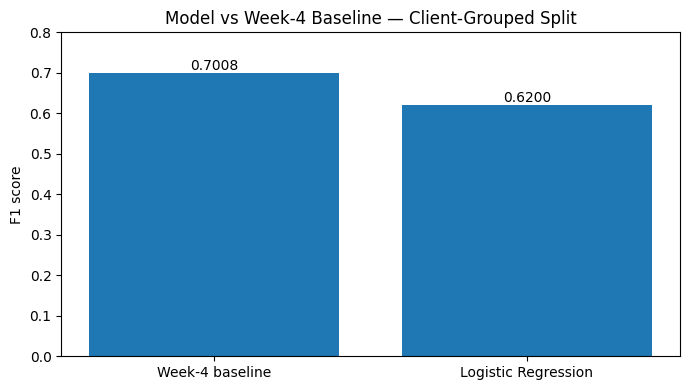


KEY RESULT
----------
Baseline F1: 0.7008
Logistic Regression F1: 0.6200
F1 difference: -0.0808

The Week-4 baseline has the higher measured F1 on the client-grouped test split.


In [17]:
# ============================================================
# SECTION 4 — RESULTS VS BASELINE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Verified results from the client-grouped evaluation.
results = pd.DataFrame({
    "Approach": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        0.8044,
        0.7837
    ],
    "Precision": [
        0.8098,
        0.8896
    ],
    "Recall": [
        0.6176,
        0.4758
    ],
    "F1": [
        0.7008,
        0.6200
    ]
})

print("HONEST RESULTS — CLIENT-GROUPED TEST SPLIT")
print("-------------------------------------------")
display(results.round(4))


# ------------------------------------------------------------
# F1 comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

bars = plt.bar(
    results["Approach"],
    results["F1"]
)

plt.ylabel("F1 score")
plt.title("Model vs Week-4 Baseline — Client-Grouped Split")
plt.ylim(0, 0.8)

for bar, value in zip(bars, results["F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Key measured comparison
# ------------------------------------------------------------

baseline_f1 = results.loc[
    results["Approach"] == "Week-4 baseline", "F1"
].iloc[0]

model_f1 = results.loc[
    results["Approach"] == "Logistic Regression", "F1"
].iloc[0]

print("\nKEY RESULT")
print("----------")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Logistic Regression F1: {model_f1:.4f}")
print(f"F1 difference: {model_f1 - baseline_f1:.4f}")

print(
    "\nThe Week-4 baseline has the higher measured F1 "
    "on the client-grouped test split."
)

## 5. Limitations

*What this work cannot claim.*

## Limitations and honest framing

This study has several important limitations.

First, the analysis is observational. The measured relationships between February signals and March activity do not establish that any individual signal causes future activity or that changing a page will produce a specific performance improvement.

Second, the Logistic Regression model does not outperform the simple Week-4 baseline on the client-grouped test split. The measured F1 was 0.6200 for Logistic Regression compared with 0.7008 for the baseline. The model therefore should not be presented as a superior replacement for the rule-based approach.

Third, the model has limited recall on the grouped test set (0.4758). This means many March-active items were not identified by the model, so the review queue should not be interpreted as a complete list of relevant content.

Fourth, the features are limited to February search and engagement signals. Other factors may contribute to future activity but are outside the feature set used here.

Fifth, the `visible_low_ctr` rule identifies content that appears worth reviewing based on observed visibility and click-through behavior. It does not establish why the CTR is low, whether the content needs a refresh, or whether a particular editorial change would improve performance.

The results should therefore be described as **observed, measured, directional, and useful for decision-support**. The output is intended to prioritize human review, not to automate publishing, deletion, redirects, indexing decisions, or guaranteed performance improvements.

The study also does not claim to explain or reproduce Google's ranking algorithm, and it does not provide causal evidence about the effect of content refreshes.

In [18]:
# ============================================================
# SECTION 5 — LIMITATIONS CHECK
# ============================================================

limitations_checks = {
    "Causal effect claimed": False,
    "Model claimed superior to baseline": False,
    "Complete identification claimed": False,
    "Automatic editorial action claimed": False,
    "Google ranking algorithm explained": False,
    "Guaranteed performance improvement claimed": False
}

print("LIMITATIONS / CLAIM SAFETY CHECK")
print("--------------------------------")

for claim, value in limitations_checks.items():
    print(f"{claim}: {value}")

print("\nSAFE FRAMING")
print("------------")
print(
    "Results are observed, measured, directional, "
    "and intended for decision-support."
)

LIMITATIONS / CLAIM SAFETY CHECK
--------------------------------
Causal effect claimed: False
Model claimed superior to baseline: False
Complete identification claimed: False
Automatic editorial action claimed: False
Google ranking algorithm explained: False
Guaranteed performance improvement claimed: False

SAFE FRAMING
------------
Results are observed, measured, directional, and intended for decision-support.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked recommendations

The action playbook is intended to prioritize human review, not automatically change content.

### 1. Review visible low-CTR content

**Reason code:** `visible_low_ctr`  
**Action:** `REVIEW_CTR`

Prioritize content with meaningful February search visibility, average position in the top 20, and CTR below 3%.

The W07 queue contained **68,696 review candidates out of 321,546 February content items**. This is a prioritization queue rather than a claim that every candidate needs a content refresh.

### 2. Diagnose the reason for low CTR before taking action

A low CTR is an observation, not an explanation. Human reviewers should check search intent, SERP context, title and snippet relevance, content quality, freshness where relevant, business context, and measurement quality before recommending an editorial change.

### 3. Treat content age as a review signal, not an automatic refresh rule

The earlier analysis observed differences in content age between growing and declining groups. This is directional evidence only. Content age by itself should not trigger an automatic refresh because the analysis does not establish that age causes performance changes.

### Recommended operating sequence

**Rank → Review → Diagnose → Decide → Measure**

The queue ranks potential review candidates. A human then checks the context and decides whether an action is appropriate. Any subsequent change should be evaluated using measured outcomes rather than assumed to improve performance.

### No-go cases

The workflow should not automatically:

- rewrite or publish content;
- delete, redirect, or deindex content;
- make high-consequence factual changes;
- refresh content solely because it is old;
- make edits solely because CTR is low;
- claim guaranteed performance improvement;
- make decisions when measurement or indexing quality is uncertain.

The recommendations are therefore **directional decision-support**, with human review required before action.

In [19]:
# ============================================================
# SECTION 6 — RANKED RECOMMENDATIONS
# ============================================================

recommendations = pd.DataFrame({
    "rank": [1, 2, 3],
    "reason_code": [
        "visible_low_ctr",
        "low_ctr_context_check",
        "age_directional_signal"
    ],
    "action": [
        "REVIEW_CTR",
        "DIAGNOSE_CTR_CONTEXT",
        "REVIEW_FRESHNESS"
    ],
    "priority": [
        "High",
        "High",
        "Medium"
    ],
    "human_review_required": [
        True,
        True,
        True
    ]
})

print("RANKED RECOMMENDATIONS")
print("----------------------")
display(recommendations)


# ------------------------------------------------------------
# W07 queue evidence
# ------------------------------------------------------------

total_content_items = 321546
review_candidates = 68696
review_rate = review_candidates / total_content_items

print("\nW07 QUEUE EVIDENCE")
print("-----------------")
print("Total February content items:", f"{total_content_items:,}")
print("Review candidates:", f"{review_candidates:,}")
print("Review candidate rate:", f"{review_rate:.4%}")
print("Primary reason code:", "visible_low_ctr")
print("Primary action:", "REVIEW_CTR")


# ------------------------------------------------------------
# Operating rule
# ------------------------------------------------------------

print("\nOPERATING RULE")
print("--------------")
print(
    "Rank candidates, review context, diagnose the likely issue, "
    "then decide on an action. Do not automate editorial changes."
)

RANKED RECOMMENDATIONS
----------------------


,rank,reason_code,action,priority,human_review_required
0,1,visible_low_ctr,REVIEW_CTR,High,True
1,2,low_ctr_context_check,DIAGNOSE_CTR_CONTEXT,High,True
2,3,age_directional_signal,REVIEW_FRESHNESS,Medium,True



W07 QUEUE EVIDENCE
-----------------
Total February content items: 321,546
Review candidates: 68,696
Review candidate rate: 21.3643%
Primary reason code: visible_low_ctr
Primary action: REVIEW_CTR

OPERATING RULE
--------------
Rank candidates, review context, diagnose the likely issue, then decide on an action. Do not automate editorial changes.


## Paper artifacts

The following artifacts are intended for reuse in the deployed research paper:

1. Model-versus-baseline results table.
2. F1 comparison chart.
3. February content review-queue summary.
4. Ranked recommendation table.

These artifacts use aggregate, public-safe information and are intended to support the Results and Ranked Recommendations sections of the paper.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# ML-12 — 5-Minute Demo Outline

## 1. Question — 45 seconds

Can February search visibility and engagement signals help identify content items that warrant human review for future activity and click-through opportunities?

The decision supported is which content items a content analyst should review first.

## 2. Method — 60 seconds

The analysis uses February search and engagement signals to predict March activity.

Five February features were used:

- Google Search Console impressions
- Google Search Console clicks
- Google Search Console average position
- GA4 sessions
- Scroll events

A Logistic Regression model was evaluated using a client-grouped 80/20 split, with the Week-4 rule-based baseline evaluated on the same test set.

## 3. One chart — 45 seconds

Show the **Model vs Week-4 Baseline — F1 Score** chart.

The chart shows F1 of 0.7008 for the Week-4 baseline and 0.6200 for Logistic Regression.

## 4. One honest result — 60 seconds

The Logistic Regression model achieved higher precision (0.8896 vs 0.8098), but lower recall (0.4758 vs 0.6176), accuracy (0.7837 vs 0.8044), and F1 (0.6200 vs 0.7008).

Therefore, the learned model did not outperform the simple baseline on the honest client-grouped test split.

## 5. One recommendation — 30 seconds

Use the resulting evidence to prioritize human review of visible low-CTR content.

The W07 action queue contained 68,696 review candidates from 321,546 February content items.

The queue should be treated as decision-support. Human reviewers should diagnose context before taking any editorial action.

## Closing message

The main takeaway is that honest validation changed the interpretation of the model. The work provides measured, directional decision-support, but it does not establish causal effects or justify automatic content changes.

,Approach,Accuracy,Precision,Recall,F1
0,Week-4 baseline,0.8044,0.8098,0.6176,0.7008
1,Logistic Regression,0.7837,0.8896,0.4758,0.6200


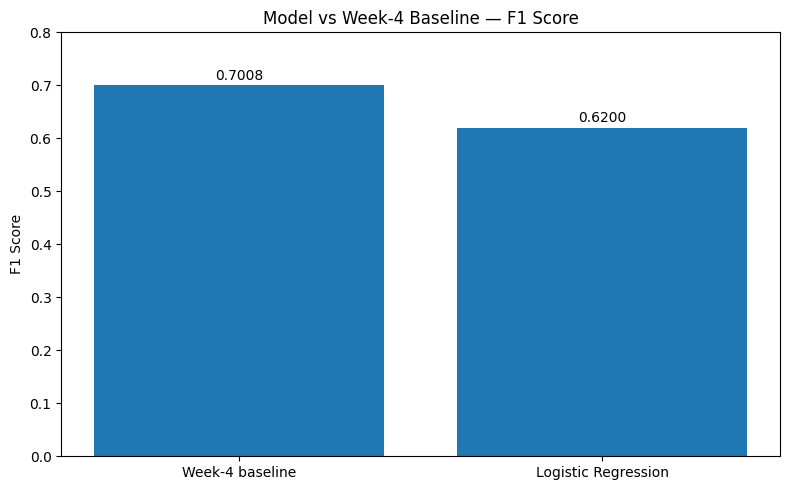

,Category,Count
0,All February content,321546
1,Review queue,68696


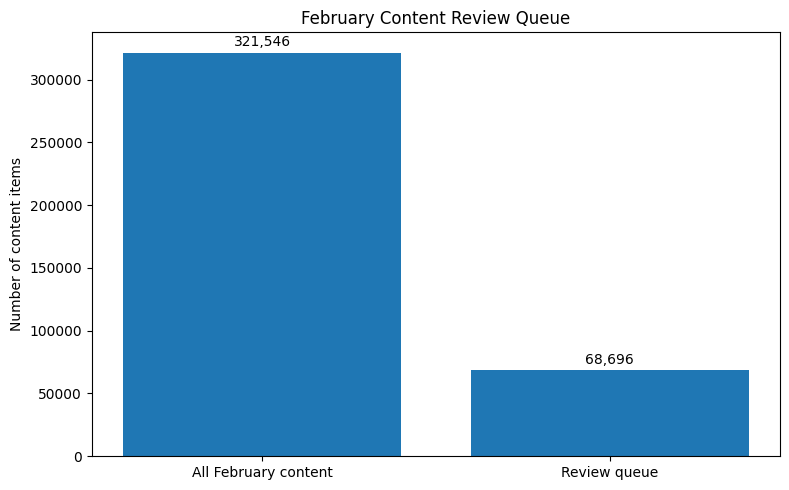

,rank,reason_code,action,priority,human_review_required
0,1,visible_low_ctr,REVIEW_CTR,High,True
1,2,low_ctr_context_check,DIAGNOSE_CTR_CONTEXT,High,True
2,3,age_directional_signal,REVIEW_FRESHNESS,Medium,True



ARTIFACT SUMMARY
----------------
1. Model vs baseline comparison table
2. Model vs baseline F1 chart
3. February content review queue chart
4. Ranked recommendations table

All artifacts use public-safe aggregate information.


In [20]:
# ============================================================
# SECTION 7 — ARTIFACTS THE PAPER EMBEDS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# Artifact 1 — Model vs baseline
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Approach": ["Week-4 baseline", "Logistic Regression"],
    "Accuracy": [0.8044, 0.7837],
    "Precision": [0.8098, 0.8896],
    "Recall": [0.6176, 0.4758],
    "F1": [0.7008, 0.6200]
})

display(comparison)

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Approach"],
    comparison["F1"]
)

for i, value in enumerate(comparison["F1"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.title("Model vs Week-4 Baseline — F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Artifact 2 — Review queue size
# ------------------------------------------------------------

queue_summary = pd.DataFrame({
    "Category": ["All February content", "Review queue"],
    "Count": [321546, 68696]
})

display(queue_summary)

plt.figure(figsize=(8, 5))

plt.bar(
    queue_summary["Category"],
    queue_summary["Count"]
)

for i, value in enumerate(queue_summary["Count"]):
    plt.text(i, value + 5000, f"{value:,}", ha="center")

plt.title("February Content Review Queue")
plt.ylabel("Number of content items")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Artifact 3 — Ranked recommendations
# ------------------------------------------------------------

display(recommendations)


# ------------------------------------------------------------
# Artifact summary
# ------------------------------------------------------------

print("\nARTIFACT SUMMARY")
print("----------------")
print("1. Model vs baseline comparison table")
print("2. Model vs baseline F1 chart")
print("3. February content review queue chart")
print("4. Ranked recommendations table")
print()
print("All artifacts use public-safe aggregate information.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
